# Scrapping

In [ ]:
pip install openmeteo-requests

In [ ]:
pip install requests-cache retry-requests numpy pandas

In [ ]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://air-quality-api.open-meteo.com/v1/air-quality"

locations = [
    {"name": "Ambon City", "latitude": -3.6958,      "longitude": 128.1833},
    {"name": "Bali", "latitude": -8.3333, "longitude": 115},
    {"name": "Balikpapan", "latitude": -1.2674, "longitude": 116.8310},
    {"name": "Bandung", "latitude": -6.9222, "longitude": 107.6069},
    {"name": "Banda Aceh", "latitude": 5.5417,  "longitude": 95.3333},
    {"name": "Bekasi", "latitude": -6.2349, "longitude": 106.9896},
    {"name": "Gorontalo", "latitude": 0.5375,  "longitude": 123.0625},
    {"name": "Jakarta", "latitude": -6.2088, "longitude": 106.8456},
    {"name": "Jayapura", "latitude": -2.5337,   "longitude": 140.7181},
    {"name": "Jogja", "latitude": -3.4292, "longitude": 119.222},
    {"name": "Kendari", "latitude": -3.9778,   "longitude": 122.5151},
    {"name": "Kupang", "latitude": -10.1708,    "longitude": 123.6069},
    {"name": "Makassar", "latitude": 0.9039, "longitude": 122.7586},
    {"name": "Manado", "latitude": 1.4822,      "longitude": 124.8489},
    {"name": "Mataram", "latitude": -8.5833,   "longitude": 116.1167},
    {"name": "Medan", "latitude": 3.5833, "longitude": 98.6667},
    {"name": "Merauke", "latitude": -8.4996,     "longitude": 140.4061},
    {"name": "Padang", "latitude": -0.9492, "longitude": 100.3543},
    {"name": "Palangkaraya", "latitude": -2.2083,"longitude": 113.9165},
    {"name": "Palembang", "latitude": -2.9167, "longitude": 104.7458},
    {"name": "Palu", "latitude": -0.9083,       "longitude": 119.8708},
    {"name": "Pekanbaru", "latitude": 0.5167, "longitude": 101.4417},
    {"name": "Pontianak", "latitude": -0.0319,   "longitude": 109.325},
    {"name": "Samarinda", "latitude": -0.4917,   "longitude": 117.1458},
    {"name": "Semarang", "latitude": -6.9931, "longitude": 110.4208},
    {"name": "Surabaya", "latitude": -7.2575, "longitude": 112.7521},
    {"name": "Tarakan", "latitude": 3.3133,      "longitude": 117.5915},
    {"name": "Tegal", "latitude": -6.8694, "longitude": 109.1402},
    {"name": "Ternate", "latitude": 0.7906,      "longitude": 127.3842},
    {"name": "Wonosobo", "latitude": -7.3589, "longitude": 109.9031}
]

all_hourly_dataframes = []

for location in locations:
    print(f"Fetching data for {location['name']}...")
    params = {
        "latitude": location["latitude"],
        "longitude": location["longitude"],
        "hourly": ["us_aqi", "us_aqi_pm2_5", "us_aqi_nitrogen_dioxide", "us_aqi_carbon_monoxide", "us_aqi_ozone", "us_aqi_pm10", "us_aqi_sulphur_dioxide"],
        "timezone": "auto",
        "start_date": "2025-09-10",
        "end_date": "2025-10-10",
    }
    responses = openmeteo.weather_api(url, params=params)

    # Process first location. Add a for-loop for multiple locations or weather models
    response = responses[0]
    print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    hourly_us_aqi = hourly.Variables(0).ValuesAsNumpy()
    hourly_us_aqi_pm2_5 = hourly.Variables(1).ValuesAsNumpy()
    hourly_us_aqi_nitrogen_dioxide = hourly.Variables(2).ValuesAsNumpy()
    hourly_us_aqi_carbon_monoxide = hourly.Variables(3).ValuesAsNumpy()
    hourly_us_aqi_ozone = hourly.Variables(4).ValuesAsNumpy()
    hourly_us_aqi_pm10 = hourly.Variables(5).ValuesAsNumpy()
    hourly_us_aqi_sulphur_dioxide = hourly.Variables(6).ValuesAsNumpy()

    hourly_data = {
        "date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        )
    }

    hourly_data["us_aqi"] = hourly_us_aqi
    hourly_data["us_aqi_pm2_5"] = hourly_us_aqi_pm2_5
    hourly_data["us_aqi_nitrogen_dioxide"] = hourly_us_aqi_nitrogen_dioxide
    hourly_data["us_aqi_carbon_monoxide"] = hourly_us_aqi_carbon_monoxide
    hourly_data["us_aqi_ozone"] = hourly_us_aqi_ozone
    hourly_data["us_aqi_pm10"] = hourly_us_aqi_pm10
    hourly_data["us_aqi_sulphur_dioxide"] = hourly_us_aqi_sulphur_dioxide

    hourly_dataframe_single_location = pd.DataFrame(data = hourly_data)
    hourly_dataframe_single_location['location_name'] = location['name']
    all_hourly_dataframes.append(hourly_dataframe_single_location)

# Concatenate all dataframes into a single one
overall_hourly_dataframe = pd.concat(all_hourly_dataframes, ignore_index=True)
print("\nOverall Hourly Data for all locations:\n")
display(overall_hourly_dataframe.head())
display(overall_hourly_dataframe.tail())


Fetching data for Ambon City...
Coordinates: -3.6999969482421875°N 128.20001220703125°E
Elevation: 7.0 m asl
Timezone: b'Asia/Jayapura'b'GMT+9'
Timezone difference to GMT+0: 32400s
Fetching data for Bali...
Coordinates: -8.299995422363281°N 115.0°E
Elevation: 616.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Balikpapan...
Coordinates: -1.2999954223632812°N 116.80001831054688°E
Elevation: 50.0 m asl
Timezone: b'Asia/Makassar'b'GMT+8'
Timezone difference to GMT+0: 28800s
Fetching data for Bandung...
Coordinates: -6.900001525878906°N 107.60000610351562°E
Elevation: 707.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Banda Aceh...
Coordinates: 5.5°N 95.30001831054688°E
Elevation: 5.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezone difference to GMT+0: 25200s
Fetching data for Bekasi...
Coordinates: -6.1999969482421875°N 107.0°E
Elevation: 19.0 m asl
Timezone: b'Asia/Jakarta'b'GMT+7'
Timezo

,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
0,2025-09-09 15:00:00+00:00,15.596010,11.458334,0.591017,5.560386,15.596010,3.087121,0.218103,Ambon City
1,2025-09-09 16:00:00+00:00,15.132191,11.354167,0.492514,6.044686,15.132191,3.075758,0.218103,Ambon City
2,2025-09-09 17:00:00+00:00,14.726344,11.267361,0.443262,6.349034,14.726344,3.071970,0.163577,Ambon City
3,2025-09-09 18:00:00+00:00,14.436457,11.180555,0.344760,6.411836,14.436457,3.068182,0.163577,Ambon City
4,2025-09-09 19:00:00+00:00,14.320501,11.076390,0.295508,6.138889,14.320501,3.064394,0.163577,Ambon City


,date,us_aqi,us_aqi_pm2_5,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_pm10,us_aqi_sulphur_dioxide,location_name
22315,2025-10-10 12:00:00+00:00,156.024124,156.024124,7.978724,2.729469,85.416664,56.758331,3.162487,Wonosobo
22316,2025-10-10 13:00:00+00:00,155.186401,155.186401,8.224981,3.483092,75.000000,55.933338,2.998909,Wonosobo
22317,2025-10-10 14:00:00+00:00,153.921051,153.921051,8.618992,4.439614,61.819725,54.695839,2.726282,Wonosobo
22318,2025-10-10 15:00:00+00:00,151.925430,151.925430,9.013002,5.577294,48.875229,52.766670,2.399128,Wonosobo
22319,2025-10-10 16:00:00+00:00,149.447891,149.447891,9.259259,6.822464,43.773190,50.785416,1.853872,Wonosobo


In [ ]:
import numpy as np

# Create a new DataFrame with the desired structure
air_quality_data = pd.DataFrame({
    'Date': overall_hourly_dataframe['date'],
    'City': overall_hourly_dataframe['location_name'],
    'CO': overall_hourly_dataframe['us_aqi_carbon_monoxide'],
    'CO2': np.nan, # Fill with NaN as requested
    'NO2': overall_hourly_dataframe['us_aqi_nitrogen_dioxide'],
    'SO2': overall_hourly_dataframe['us_aqi_sulphur_dioxide'],
    'O3': overall_hourly_dataframe['us_aqi_ozone'],
    'PM2.5': overall_hourly_dataframe['us_aqi_pm2_5'],
    'PM10': overall_hourly_dataframe['us_aqi_pm10'],
    'AQI': overall_hourly_dataframe['us_aqi']
})

print("Restructured Air Quality Data:")
display(air_quality_data.head())
display(air_quality_data.tail())

Restructured Air Quality Data:


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2025-09-09 15:00:00+00:00,Ambon City,5.560386,NaN,0.591017,0.218103,15.596010,11.458334,3.087121,15.596010
1,2025-09-09 16:00:00+00:00,Ambon City,6.044686,NaN,0.492514,0.218103,15.132191,11.354167,3.075758,15.132191
2,2025-09-09 17:00:00+00:00,Ambon City,6.349034,NaN,0.443262,0.163577,14.726344,11.267361,3.071970,14.726344
3,2025-09-09 18:00:00+00:00,Ambon City,6.411836,NaN,0.344760,0.163577,14.436457,11.180555,3.068182,14.436457
4,2025-09-09 19:00:00+00:00,Ambon City,6.138889,NaN,0.295508,0.163577,14.320501,11.076390,3.064394,14.320501


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
22315,2025-10-10 12:00:00+00:00,Wonosobo,2.729469,NaN,7.978724,3.162487,85.416664,156.024124,56.758331,156.024124
22316,2025-10-10 13:00:00+00:00,Wonosobo,3.483092,NaN,8.224981,2.998909,75.000000,155.186401,55.933338,155.186401
22317,2025-10-10 14:00:00+00:00,Wonosobo,4.439614,NaN,8.618992,2.726282,61.819725,153.921051,54.695839,153.921051
22318,2025-10-10 15:00:00+00:00,Wonosobo,5.577294,NaN,9.013002,2.399128,48.875229,151.925430,52.766670,151.925430
22319,2025-10-10 16:00:00+00:00,Wonosobo,6.822464,NaN,9.259259,1.853872,43.773190,149.447891,50.785416,149.447891


In [ ]:
air_quality_data.to_csv('air_quality_data(fetch).csv', index=False)
print("Dataset telah berhasil disimpan")

Dataset telah berhasil disimpan


# Combining Data

In [ ]:
import pandas as pd

data1 = "https://github.com/KhalPrawira/Big-Data_Assignment/raw/refs/heads/main/Dataset/Air_Quality.csv"

data2 = "/content/air_quality_data(fetch).csv"

df1 = pd.read_csv(data1)

df2 = pd.read_csv(data2)

combined_df = pd.concat([df1, df2], ignore_index=True)

print("Dataframe pertama (df1) head:")
print(df1.head())
print("\nDataframe kedua (df2) head:")
print(df2.head())
print("\nGabungan Dataframe (combined_df) head:")
print(combined_df.head())

print(f"\nJumlah baris df1: {len(df1)}")
print(f"Jumlah baris df2: {len(df2)}")
print(f"Jumlah baris gabungan: {len(combined_df)}")

Dataframe pertama (df1) head:
                        Date      City     CO  CO2   NO2  SO2    O3  PM2.5  \
0  2024-01-01 00:00:00+00:00  Brasilia  323.0  NaN  23.8  2.8  42.0   12.0   
1  2024-01-01 01:00:00+00:00  Brasilia  318.0  NaN  21.9  2.7  40.0   12.5   
2  2024-01-01 02:00:00+00:00  Brasilia  309.0  NaN  19.2  2.6  39.0   12.1   
3  2024-01-01 03:00:00+00:00  Brasilia  295.0  NaN  16.3  2.4  38.0   11.4   
4  2024-01-01 04:00:00+00:00  Brasilia  270.0  NaN  13.0  2.1  40.0   10.2   

   PM10        AQI  
0  17.1  16.800000  
1  17.9  16.000000  
2  17.3  15.599999  
3  16.2  15.200000  
4  14.6  16.000000  

Dataframe kedua (df2) head:
                        Date        City        CO  CO2       NO2       SO2  \
0  2025-09-09 15:00:00+00:00  Ambon City  5.560386  NaN  0.591017  0.218103   
1  2025-09-09 16:00:00+00:00  Ambon City  6.044686  NaN  0.492514  0.218103   
2  2025-09-09 17:00:00+00:00  Ambon City  6.349034  NaN  0.443262  0.163577   
3  2025-09-09 18:00:00+00:00  

In [ ]:
output_filename = "combined_air_quality_data.csv"
combined_df.to_csv(output_filename, index=False)
print(f"Dataset gabungan telah berhasil disimpan ke '{output_filename}'")

Dataset gabungan telah berhasil disimpan ke 'combined_air_quality_data.csv'


# Load and Explore

In [ ]:
import pandas as pd
import numpy as np

df = "/content/combined_air_quality_data.csv"
df = pd.read_csv(df)

print("jumlah baris dan kolom: ", df.shape)
display(df.head())

jumlah baris dan kolom:  (75024, 10)


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [ ]:
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

duplicates = df.duplicated().sum()
print("\nJumlah data duplikat:", duplicates)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   CO2     9648 non-null   float64
 4   NO2     75024 non-null  float64
 5   SO2     75024 non-null  float64
 6   O3      75024 non-null  float64
 7   PM2.5   75024 non-null  float64
 8   PM10    75024 non-null  float64
 9   AQI     75024 non-null  float64
dtypes: float64(8), object(2)
memory usage: 5.7+ MB

Jumlah missing value di setiap kolom:
Date         0
City         0
CO           0
CO2      65376
NO2          0
SO2          0
O3           0
PM2.5        0
PM10         0
AQI          0
dtype: int64

Jumlah data duplikat: 0


# Data Cleaning

In [ ]:
df.drop('CO2', axis=1, inplace=True)
print("Kolom 'CO2' telah dihapus.")
df.info()

print("\nJumlah missing value di setiap kolom:")
print(df.isnull().sum())

Kolom 'CO2' telah dihapus.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75024 entries, 0 to 75023
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    75024 non-null  object 
 1   City    75024 non-null  object 
 2   CO      75024 non-null  float64
 3   NO2     75024 non-null  float64
 4   SO2     75024 non-null  float64
 5   O3      75024 non-null  float64
 6   PM2.5   75024 non-null  float64
 7   PM10    75024 non-null  float64
 8   AQI     75024 non-null  float64
dtypes: float64(7), object(2)
memory usage: 5.2+ MB

Jumlah missing value di setiap kolom:
Date     0
City     0
CO       0
NO2      0
SO2      0
O3       0
PM2.5    0
PM10     0
AQI      0
dtype: int64


# Checking Outlier

In [ ]:
print("\nMendeteksi Outlier menggunakan IQR:")

# Memilih kolom numerik untuk deteksi outlier
numerical_cols = df.select_dtypes(include=np.number).columns

outlier_count = 0
total_data_points = 0

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mendeteksi outlier
    col_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(col_outliers)
    outlier_count += num_outliers
    total_data_points += len(df[col])

    if num_outliers > 0:
        print(f"  Kolom '{col}': {num_outliers} outlier terdeteksi ({round((num_outliers / len(df[col])) * 100, 2)}% dari total data kolom ini)")
    else:
        print(f"  Kolom '{col}': Tidak ada outlier terdeteksi.")

print(f"\nTotal outlier terdeteksi di seluruh kolom numerik: {outlier_count} dari {total_data_points} data poin.")
if total_data_points > 0:
    print(f"Persentase total outlier: {round((outlier_count / total_data_points) * 100, 2)}%")
else:
    print("Tidak ada data poin untuk dianalisis.")


Mendeteksi Outlier menggunakan IQR:
  Kolom 'CO': 1969 outlier terdeteksi (2.62% dari total data kolom ini)
  Kolom 'NO2': 2680 outlier terdeteksi (3.57% dari total data kolom ini)
  Kolom 'SO2': 6397 outlier terdeteksi (8.53% dari total data kolom ini)
  Kolom 'O3': 2540 outlier terdeteksi (3.39% dari total data kolom ini)
  Kolom 'PM2.5': 4314 outlier terdeteksi (5.75% dari total data kolom ini)
  Kolom 'PM10': 7778 outlier terdeteksi (10.37% dari total data kolom ini)
  Kolom 'AQI': 4771 outlier terdeteksi (6.36% dari total data kolom ini)

Total outlier terdeteksi di seluruh kolom numerik: 30449 dari 525168 data poin.
Persentase total outlier: 5.8%


Menampilkan outlier menggunakan Box Plot:


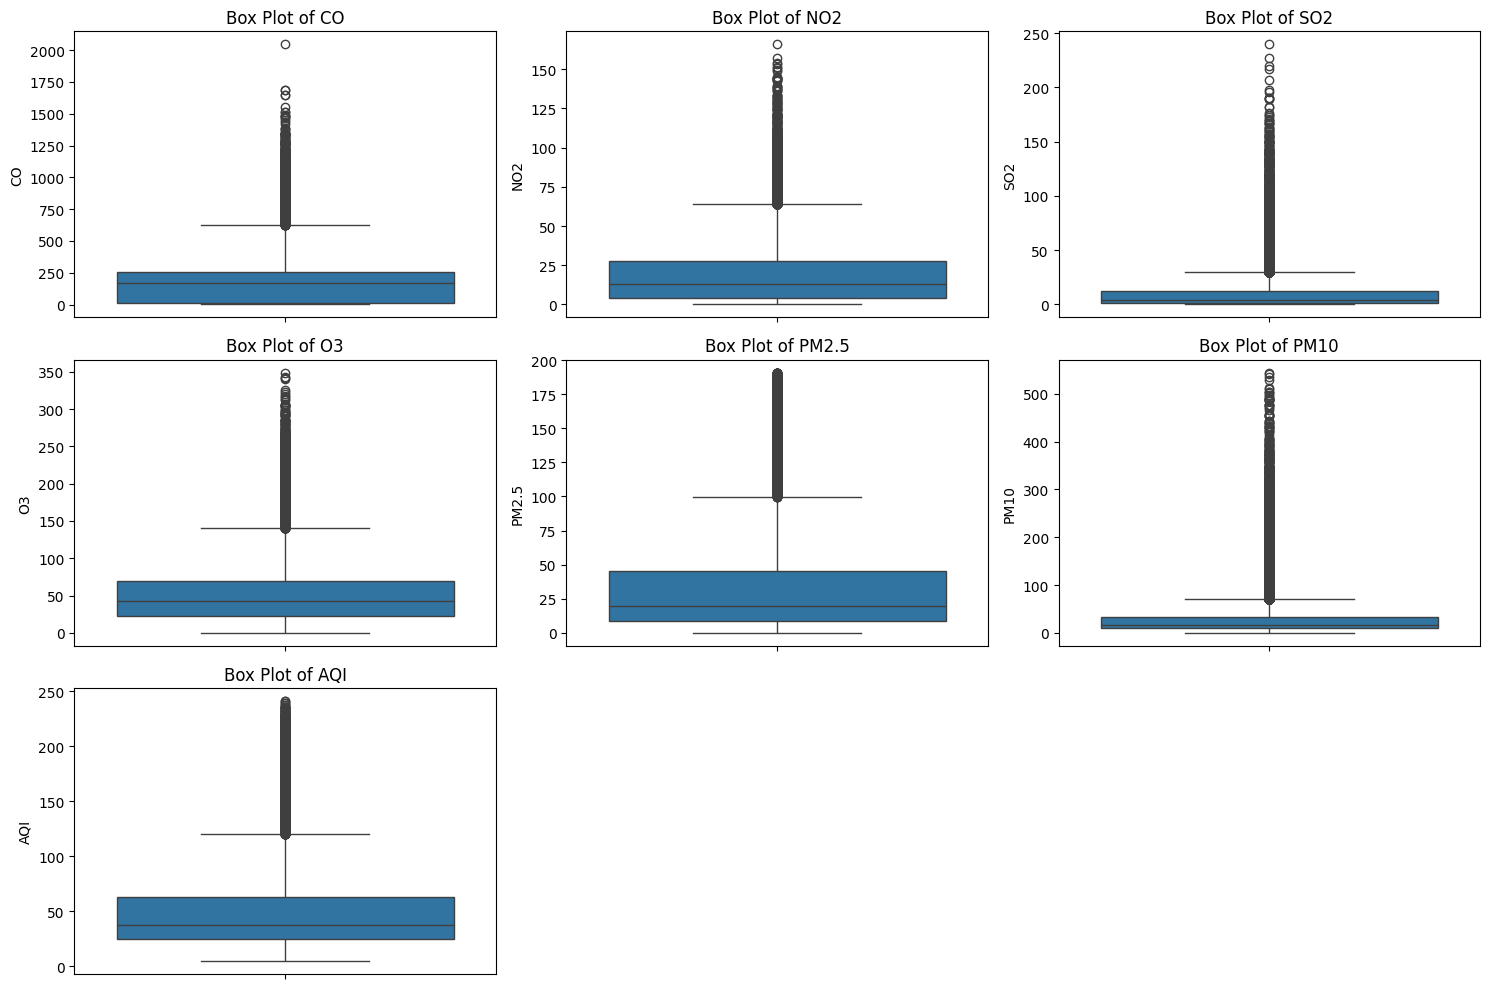

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Menampilkan outlier menggunakan Box Plot:")

# Memilih kolom numerik untuk menampilkan outlier
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

# EDA

Membuat heatmap korelasi:


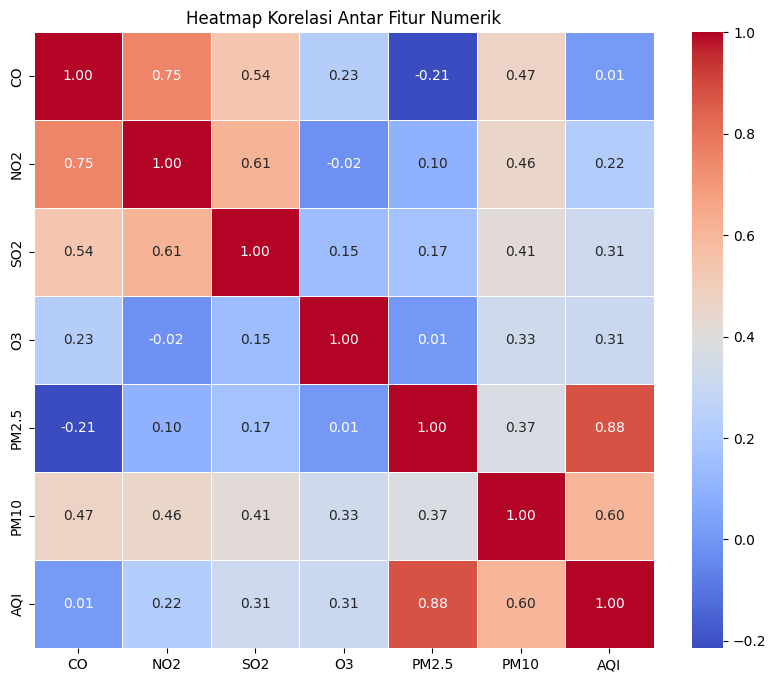

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Membuat heatmap korelasi:")

# Memilih kolom numerik
numerical_cols = df.select_dtypes(include=np.number).columns

# Menghitung matriks korelasi
correlation_matrix = df[numerical_cols].corr()

# Membuat heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

# Preparing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['NO2','SO2','O3','PM2.5','PM10']]
y = df['AQI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data train:", X_train.shape)
print("Data test :", X_test.shape)

Data train: (60019, 5)
Data test : (15005, 5)


# Modeling

* Linear Regression

📈 Linear Regression Results:
Mean Absolute Error (MAE): 7.0
R² Score: 0.911

Cross-validation R² Scores: [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score: 0.913
Std Dev CV R² Score: 0.002


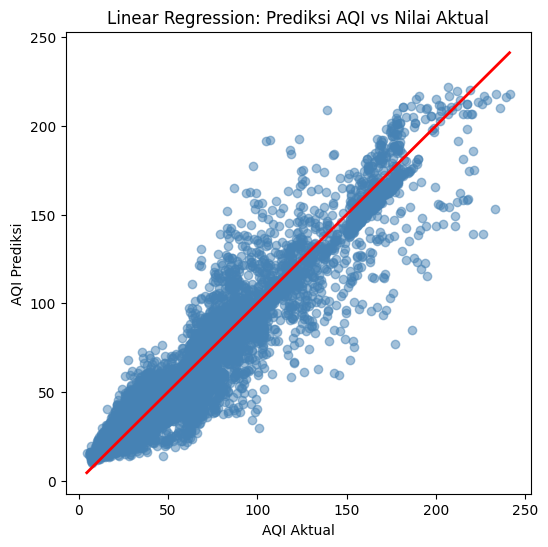

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import matplotlib.pyplot as plt

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("📈 Linear Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lr, 2))
print("R² Score:", round(r2_lr, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores])
print("Mean CV R² Score:", round(cv_scores.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Linear Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Random Forest

🌳 Random Forest Results:
Mean Absolute Error (MAE): 3.61
R² Score: 0.961

Cross-validation R² Scores: [np.float64(0.961), np.float64(0.964), np.float64(0.966), np.float64(0.963), np.float64(0.961)]
Mean CV R² Score: 0.963
Std Dev CV R² Score: 0.002


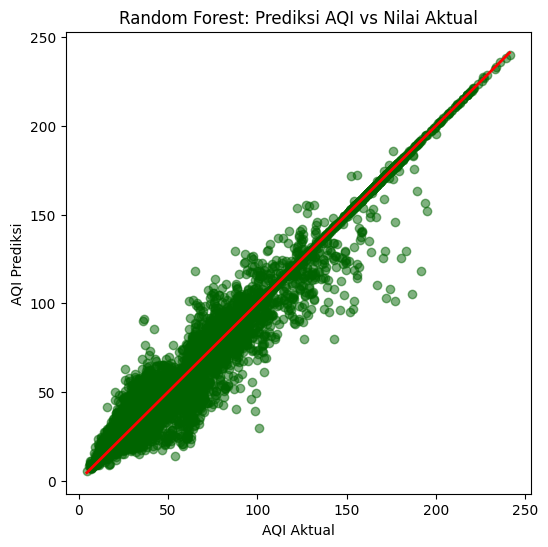

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("🌳 Random Forest Results:")
print("Mean Absolute Error (MAE):", round(mae_rf, 2))
print("R² Score:", round(r2_rf, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_rf = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_rf])
print("Mean CV R² Score:", round(cv_scores_rf.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_rf.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, color='darkgreen')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Random Forest: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Decission Tree

🌲 Decision Tree Results:
MAE: 5.01
R² : 0.946

Cross-validation R² Scores: [np.float64(0.946), np.float64(0.949), np.float64(0.951), np.float64(0.948), np.float64(0.948)]
Mean CV R² Score: 0.949
Std Dev CV R² Score: 0.002


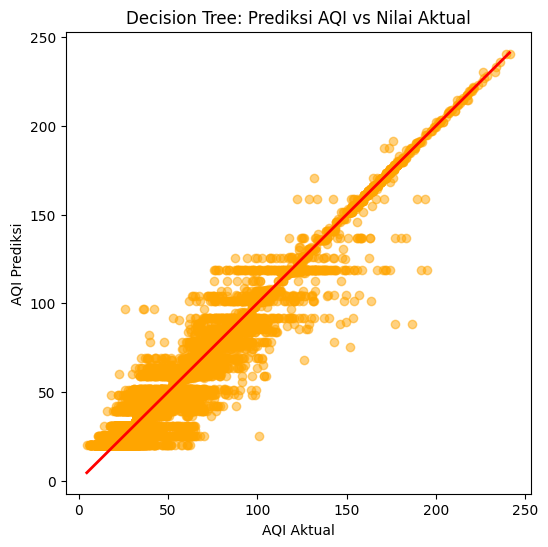

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score

dt_model = DecisionTreeRegressor(random_state=42, max_depth=8)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("🌲 Decision Tree Results:")
print("MAE:", round(mae_dt, 2))
print("R² :", round(r2_dt, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(dt_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_dt])
print("Mean CV R² Score:", round(cv_scores_dt.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_dt.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_dt, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Decision Tree: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* KNN

👥 K-Nearest Neighbors Results:
MAE: 3.86
R² : 0.957

Cross-validation R² Scores: [np.float64(0.957), np.float64(0.959), np.float64(0.962), np.float64(0.958), np.float64(0.955)]
Mean CV R² Score: 0.958
Std Dev CV R² Score: 0.002


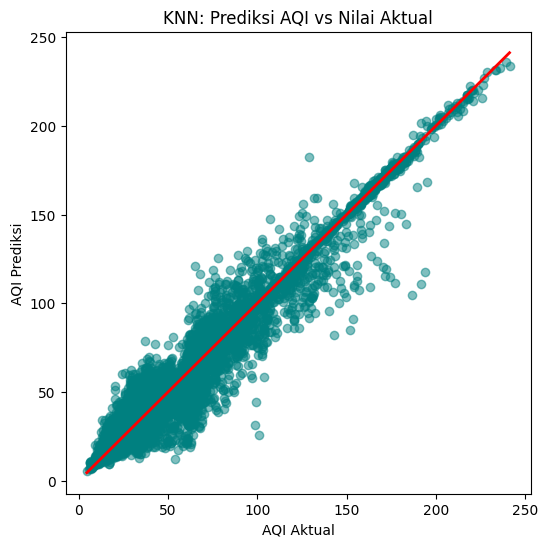

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, cross_val_score

knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

mae_knn = mean_absolute_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("👥 K-Nearest Neighbors Results:")
print("MAE:", round(mae_knn, 2))
print("R² :", round(r2_knn, 3))

# Cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_knn = cross_val_score(knn_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_knn])
print("Mean CV R² Score:", round(cv_scores_knn.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_knn.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_knn, alpha=0.5, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("KNN: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* XGBoost

🚀 XGBoost Results:
Mean Absolute Error (MAE): 4.02
R² Score: 0.958

Cross-validation R² Scores: [np.float64(0.958), np.float64(0.961), np.float64(0.962), np.float64(0.96), np.float64(0.958)]
Mean CV R² Score: 0.96
Std Dev CV R² Score: 0.002


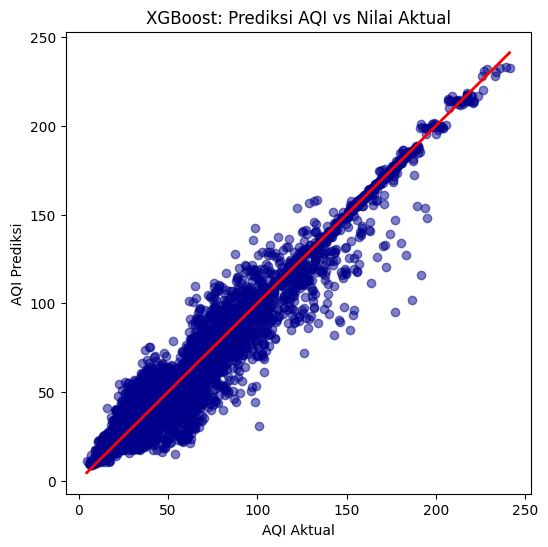

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("🚀 XGBoost Results:")
print("Mean Absolute Error (MAE):", round(mae_xgb, 2))
print("R² Score:", round(r2_xgb, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_xgb = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_xgb])
print("Mean CV R² Score:", round(cv_scores_xgb.mean(), 3))
print("Std Dev CV R² Score:", round(cv_scores_xgb.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='darkblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("XGBoost: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Gradient Boosting

🚀 Gradient Boosting Regressor Results:
Mean Absolute Error (MAE): 4.61
R² Score: 0.949

Cross-validation R² Scores (Gradient Boosting): [np.float64(0.949), np.float64(0.951), np.float64(0.954), np.float64(0.949), np.float64(0.949)]
Mean CV R² Score (Gradient Boosting): 0.95
Std Dev CV R² Score (Gradient Boosting): 0.002


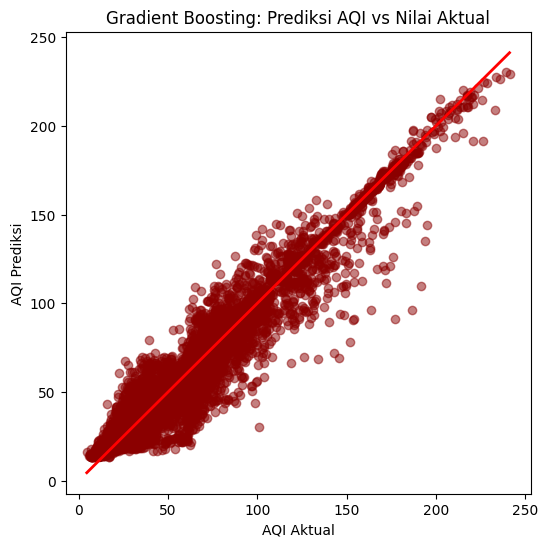

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

gbr_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr_model.fit(X_train, y_train)

y_pred_gbr = gbr_model.predict(X_test)

mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("🚀 Gradient Boosting Regressor Results:")
print("Mean Absolute Error (MAE):", round(mae_gbr, 2))
print("R² Score:", round(r2_gbr, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_gbr = cross_val_score(gbr_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Gradient Boosting):", [round(score, 3) for score in cv_scores_gbr])
print("Mean CV R² Score (Gradient Boosting):", round(cv_scores_gbr.mean(), 3))
print("Std Dev CV R² Score (Gradient Boosting):", round(np.std(cv_scores_gbr), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_gbr, alpha=0.5, color='darkred')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Gradient Boosting: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* LightBGM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003186 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 60019, number of used features: 5
[LightGBM] [Info] Start training from score 50.239324
💡 LightGBM Results:
Mean Absolute Error (MAE): 4.11
R² Score: 0.957
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003213 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train set: 60019, number of used features: 5
[LightGBM] [Info] Start training from score 50.239324
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003026 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1275
[LightGBM] [Info] Number of data points in the train

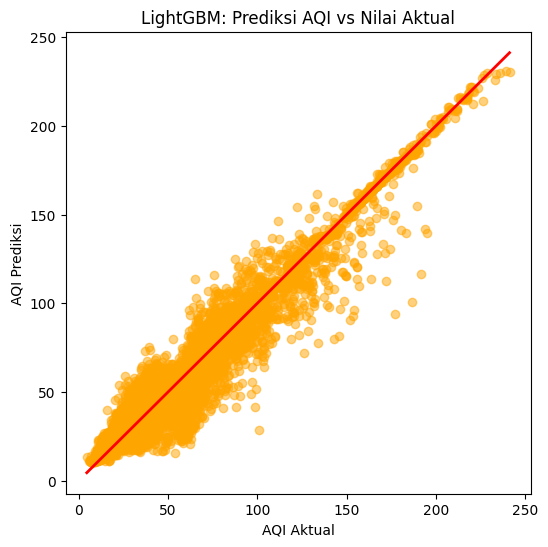

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
lgbm_model.fit(X_train, y_train)

y_pred_lgbm = lgbm_model.predict(X_test)

mae_lgbm = mean_absolute_error(y_test, y_pred_lgbm)
r2_lgbm = r2_score(y_test, y_pred_lgbm)

print("💡 LightGBM Results:")
print("Mean Absolute Error (MAE):", round(mae_lgbm, 2))
print("R² Score:", round(r2_lgbm, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lgbm = cross_val_score(lgbm_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores:", [round(score, 3) for score in cv_scores_lgbm])
print("Mean CV R² Score:", round(cv_scores_lgbm.mean(), 3))
print("Std Dev CV R² Score:", round(np.std(cv_scores_lgbm), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lgbm, alpha=0.5, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("LightGBM: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

 * Ridge Regression

🏔️ Ridge Regression Results:
Mean Absolute Error (MAE): 7.0
R² Score: 0.911

Cross-validation R² Scores (Ridge): [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score (Ridge): 0.913
Std Dev CV R² Score (Ridge): 0.002


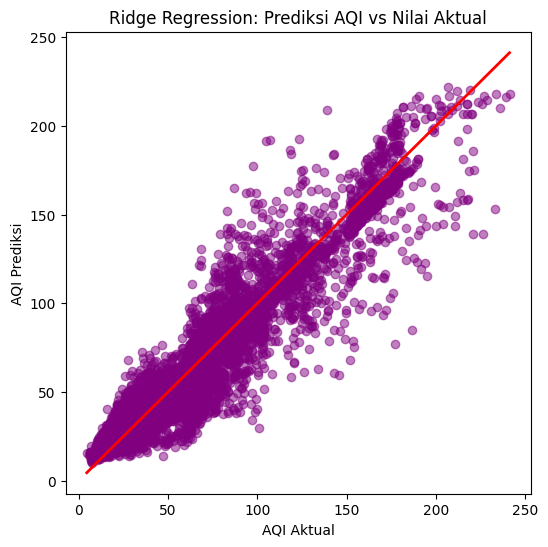

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

ridge_model = Ridge(alpha=1.0, random_state=42)
ridge_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("🏔️ Ridge Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_ridge, 2))
print("R² Score:", round(r2_ridge, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_ridge = cross_val_score(ridge_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Ridge):", [round(score, 3) for score in cv_scores_ridge])
print("Mean CV R² Score (Ridge):", round(cv_scores_ridge.mean(), 3))
print("Std Dev CV R² Score (Ridge):", round(cv_scores_ridge.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_ridge, alpha=0.5, color='purple')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Ridge Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

* Lasso Regression


🪢 Lasso Regression Results:
Mean Absolute Error (MAE): 7.0
R² Score: 0.911

Cross-validation R² Scores (Lasso): [np.float64(0.911), np.float64(0.914), np.float64(0.918), np.float64(0.912), np.float64(0.913)]
Mean CV R² Score (Lasso): 0.913
Std Dev CV R² Score (Lasso): 0.002


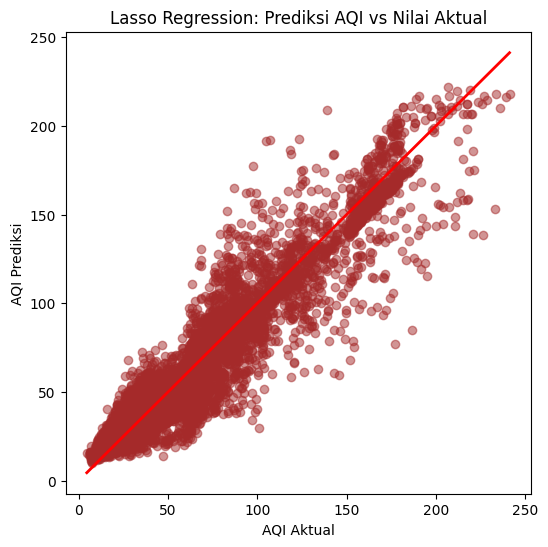

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

lasso_model = Lasso(alpha=0.1, random_state=42)
lasso_model.fit(X_train, y_train)

y_pred_lasso = lasso_model.predict(X_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("\n🪢 Lasso Regression Results:")
print("Mean Absolute Error (MAE):", round(mae_lasso, 2))
print("R² Score:", round(r2_lasso, 3))

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lasso = cross_val_score(lasso_model, X, y, cv=kf, scoring='r2')

print("\nCross-validation R² Scores (Lasso):", [round(score, 3) for score in cv_scores_lasso])
print("Mean CV R² Score (Lasso):", round(cv_scores_lasso.mean(), 3))
print("Std Dev CV R² Score (Lasso):", round(cv_scores_lasso.std(), 3))

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lasso, alpha=0.5, color='brown')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2)
plt.title("Lasso Regression: Prediksi AQI vs Nilai Aktual")
plt.xlabel("AQI Aktual")
plt.ylabel("AQI Prediksi")
plt.show()

,Model,MAE,R² Score
1,Random Forest,3.610038,0.961023
3,KNN,3.856276,0.956988
4,XGBoost,4.020188,0.957718
5,LightGBM,4.106708,0.957300
8,Gradient Boosting Regressor,4.608873,0.949313
2,Decision Tree,5.007447,0.946459
0,Linear Regression,6.998160,0.910886
6,Ridge Regression,6.998160,0.910886
7,Lasso Regression,6.999153,0.910888


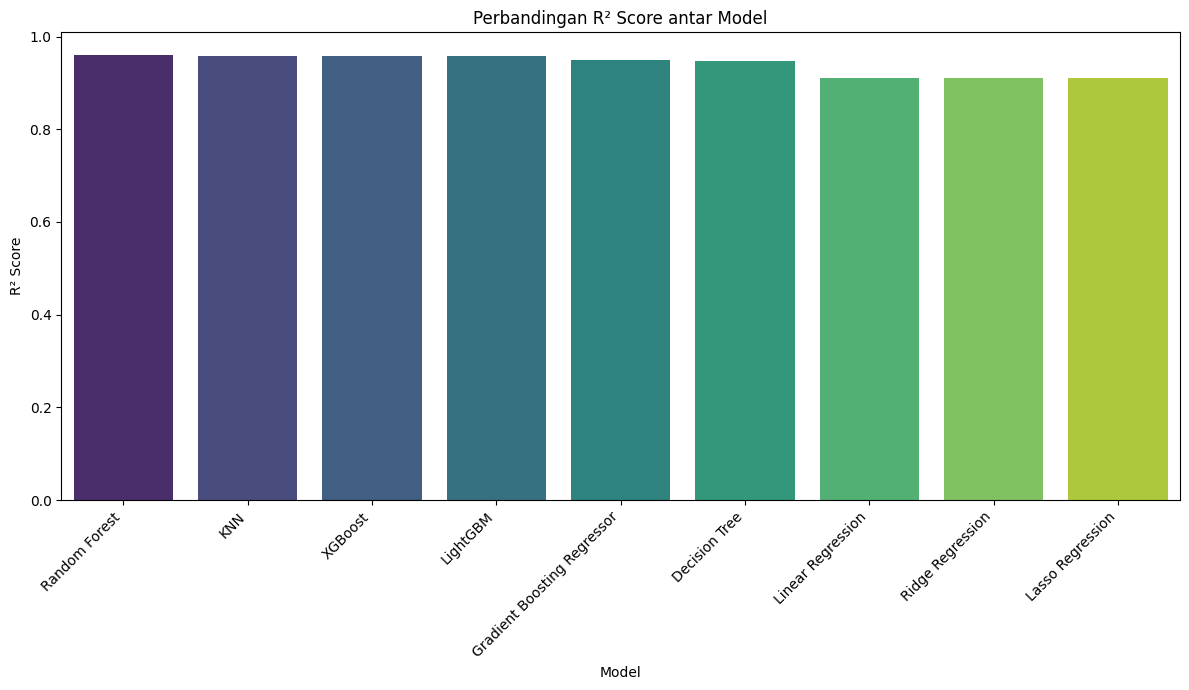

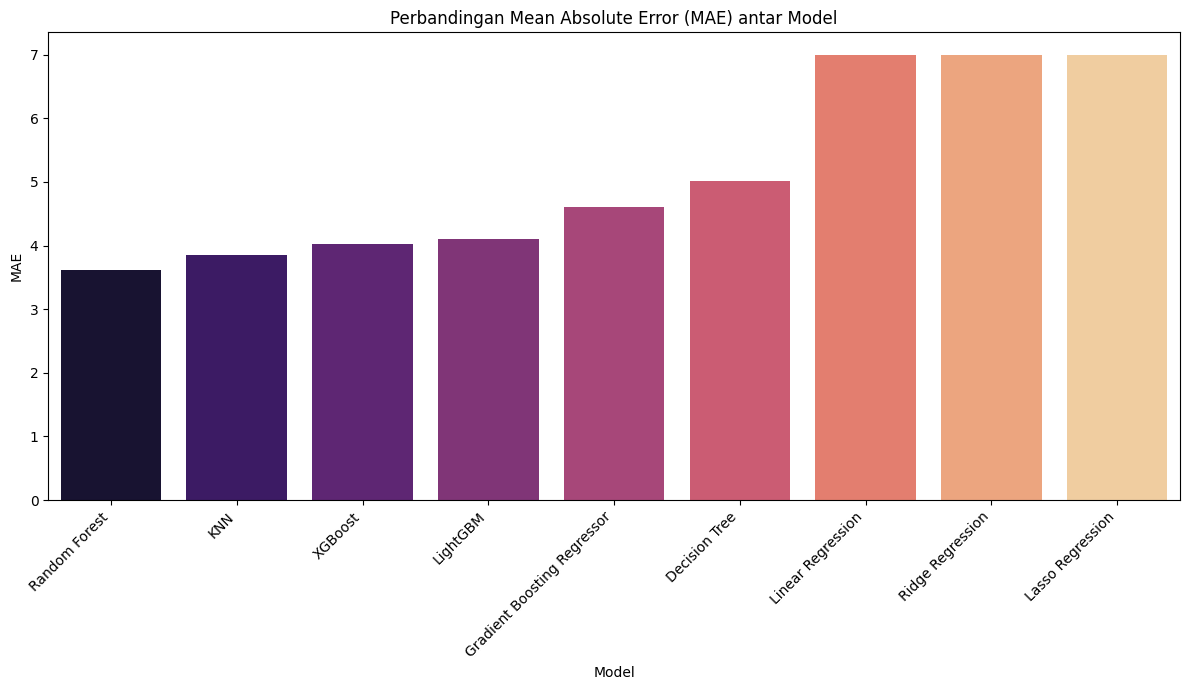

In [ ]:
models = [
    'Linear Regression',
    'Random Forest',
    'Decision Tree',
    'KNN',
    'XGBoost',
    'LightGBM',
    'Ridge Regression',
    'Lasso Regression',
    'Gradient Boosting Regressor'
]
mae_scores = [
    mae_lr,
    mae_rf,
    mae_dt,
    mae_knn,
    mae_xgb,
    mae_lgbm,
    mae_ridge,
    mae_lasso,
    mae_gbr
]
r2_scores = [
    r2_lr,
    r2_rf,
    r2_dt,
    r2_knn,
    r2_xgb,
    r2_lgbm,
    r2_ridge,
    r2_lasso,
    r2_gbr
]

results_df = pd.DataFrame({
    'Model': models,
    'MAE': mae_scores,
    'R² Score': r2_scores
}).sort_values(by='MAE')

display(results_df)

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='R² Score', data=results_df, palette='viridis', hue='Model', legend=False)
plt.title('Perbandingan R² Score antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('R² Score')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='MAE', data=results_df.sort_values(by='MAE', ascending=True), palette='magma', hue='Model', legend=False)
plt.title('Perbandingan Mean Absolute Error (MAE) antar Model')
plt.xticks(rotation=45, ha='right')
plt.ylabel('MAE')
plt.tight_layout()
plt.show()

# Pengujian Model

## Menyimpan Model Terbaik

In [ ]:
import joblib

joblib.dump(rf_model, "")

print("✅ Model", rf_model, "terbaik berhasil disimpan")

## Uji Model

* Input User

* Realtime